<a href="https://colab.research.google.com/github/tlsrudwns111/20250515yolo/blob/20250515yolo(1)/yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 181818181818.png to 181818181818.png

image 1/1 /content/181818181818.png: 640x640 3 cats, 6 dogs, 689.1ms
Speed: 5.1ms preprocess, 689.1ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)
⚠️ 강아지 감지 (무시함) (conf=0.94) → 위치: [878.962158203125, 487.2217102050781, 1269.209716796875, 875.064697265625]
⚠️ 강아지 감지 (무시함) (conf=0.93) → 위치: [0.313262939453125, 936.4030151367188, 425.09576416015625, 1279.219970703125]
⚠️ 강아지 감지 (무시함) (conf=0.93) → 위치: [883.01318359375, 976.6943359375, 1278.86376953125, 1279.23046875]
⚠️ 강아지 감지 (무시함) (conf=0.92) → 위치: [472.163818359375, 869.6856689453125, 821.0322265625, 1279.4625244140625]
✅ 고양이 감지 (conf=0.92) → 위치: [7.102752685546875, 432.3463134765625, 404.3650207519531, 866.7349853515625]
✅ 고양이 감지 (conf=0.91) → 위치: [24.5009765625, 27.2293701171875, 342.8529052734375, 425.7498779296875]
✅ 고양이 감지 (conf=0.91) → 위치: [886.7330322265625, 0.0, 1235.0797119140625, 429.0798034667969]
⚠️ 강아지 감지 (무시함) (conf=0.86) → 위치: [434.1326904296875, 0.0, 843.8

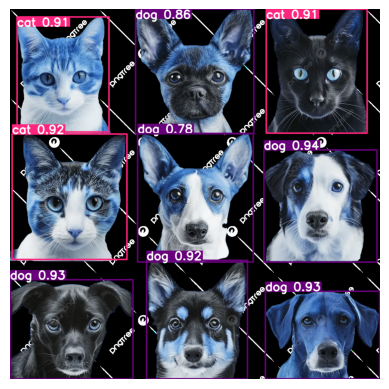

In [4]:
# 1. ultralytics 설치 (처음 한 번만)
!pip install ultralytics

# 2. 모델 로드
from ultralytics import YOLO
model = YOLO('yolov8s.pt')  # 정확도 높이기 위해 's' 버전 사용

# 3. 이미지 업로드
from google.colab import files
uploaded = files.upload()
image_path = next(iter(uploaded))

# 4. 감지 수행 (confidence 높여서 오탐 줄이기)
results = model(image_path, conf=0.4)

# 5. 고양이만 세고, 강아지는 표시만 하기
cat_count = 0

for result in results:
    boxes = result.boxes
    for box in boxes:
        cls = int(box.cls[0])
        label = model.names[cls]
        conf = box.conf[0].item()  # confidence 점수

        if label == 'cat':
            cat_count += 1
            print(f"✅ 고양이 감지 (conf={conf:.2f}) → 위치: {box.xyxy[0].tolist()}")
        elif label == 'dog':
            print(f"⚠️ 강아지 감지 (무시함) (conf={conf:.2f}) → 위치: {box.xyxy[0].tolist()}")

print(f"\n🐱 최종 고양이 수: {cat_count}마리")

# 6. 시각화 결과 보기
import matplotlib.pyplot as plt
plt.imshow(results[0].plot())
plt.axis('off')
plt.show()

